# Deep Learning Assignment 1: Facial Expression Analysis
## NUCES FAST, Islamabad

**Instructors:** Mahnoor Tariq & Dr. Qurat Ul Ain  
**Due Date:** 27th September 2025

### Assignment Overview
This assignment focuses on implementing CNN models for:
1. **Facial Expression Recognition** - 8 emotion categories (0: Neutral, 1: Happy, 2: Sad, 3: Surprise, 4: Fear, 5: Disgust, 6: Anger, 7: Contempt)
2. **Valence and Arousal Prediction** - Continuous values in [-1, +1] range

### Dataset Information
- **Images:** 3999 face images (224x224 RGB)
- **Annotations:** 15996 .npy files containing:
  - Expression labels (0-7)
  - Valence values [-1, +1]
  - Arousal values [-1, +1] 
  - 68 facial landmarks (136 coordinates)

### Requirements Fulfilled
- ✅ Multiple CNN architectures (ResNet50, VGG16)
- ✅ All evaluation metrics (Accuracy, F1, Kappa, Alpha, AUC, RMSE, CORR, SAGR, CCC)
- ✅ Modular, object-oriented implementation
- ✅ Data augmentation
- ✅ Transfer learning
- ✅ Comprehensive performance comparison


# Facial Expression Analysis – PyTorch

This notebook implements a multi-task PyTorch solution for facial expression analysis:
- **8-class classification** of facial expressions
- **Valence** and **Arousal** regression (both in [-1, 1])

Uses transfer learning with ResNet50 and VGG-16 backbone and provides comprehensive metrics and training loop.


## Imports 

In [48]:
import os
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from scipy.stats import pearsonr
import pandas as pd
import shutil

## Setup

In [49]:
ImageFile.LOAD_TRUNCATED_IMAGES = True


def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def print_gpu_memory():
    if not torch.cuda.is_available():
        print("GPU not available.")
        return
    torch.cuda.synchronize()
    mem_alloc = torch.cuda.memory_allocated() / (1024**2)
    mem_reserved = torch.cuda.memory_reserved() / (1024**2)
    print(f"GPU mem | allocated: {mem_alloc:.1f} MB | reserved: {mem_reserved:.1f} MB")


def get_tqdm_ncols():
    """Return None to let tqdm pick a dynamic width across terminals/notebooks."""
    return None

try:
    import torch.multiprocessing as mp
    mp.set_start_method("spawn", force=False)
except Exception:
    pass

from contextlib import contextmanager
@contextmanager
def amp_autocast(enabled: bool):
    if torch.cuda.is_available():
        with torch.amp.autocast('cuda', enabled=enabled):
            yield
    else:
        yield

## Dataset Preperation

In [50]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")


def discover_indices(images_dir: Path, ann_dir: Path) -> List[int]:
    images_dir = Path(images_dir); ann_dir = Path(ann_dir)
    idx_set = set()
    for p in images_dir.iterdir():
        if not p.is_file() or p.suffix not in IMG_EXTS:
            continue
        stem = p.stem
        try:
            i = int(stem)
        except ValueError:
            continue
        need = [ann_dir / f"{i}_exp.npy", ann_dir / f"{i}_val.npy", ann_dir / f"{i}_aro.npy"]
        if all(q.exists() for q in need):
            idx_set.add(i)
    return sorted(idx_set)


def aggregate_annotation_arrays(indices: List[int], ann_dir: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    labels, valence, arousal = [], [], []
    for i in indices:
        labels.append(np.load(ann_dir / f"{i}_exp.npy").squeeze())
        valence.append(np.load(ann_dir / f"{i}_val.npy").squeeze())
        arousal.append(np.load(ann_dir / f"{i}_aro.npy").squeeze())
    return np.asarray(labels).astype(int), np.asarray(valence).astype(np.float32), np.asarray(arousal).astype(np.float32)


## Data Loading

In [51]:
class FacialAffectDataset(Dataset):
    def __init__(self, images_dir: Path, ann_dir: Path, indices: List[int], train: bool = True):
        self.images_dir = Path(images_dir)
        self.ann_dir = Path(ann_dir)
        self.indices = list(indices)

        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]

        if train:
            self.tfms = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])
        else:
            self.tfms = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])

    def __len__(self):
        return len(self.indices)

    def _img_path(self, i: int) -> Path:
        for ext in IMG_EXTS:
            p = self.images_dir / f"{i}{ext}"
            if p.exists():
                return p
        raise FileNotFoundError(
            f"Image file for index {i} not found in {self.images_dir} (checked {IMG_EXTS})."
        )

    def __getitem__(self, k: int):
        i = int(self.indices[k])
        try:
            img_path = self._img_path(i)
            img = Image.open(img_path).convert("RGB")
            x = self.tfms(img)
            y = int(np.load(self.ann_dir / f"{i}_exp.npy").squeeze())
            v = np.load(self.ann_dir / f"{i}_val.npy").astype(np.float32).squeeze()
            a = np.load(self.ann_dir / f"{i}_aro.npy").astype(np.float32).squeeze()
            return x, y, v, a, i
        except Exception as e:
            raise RuntimeError(
                f"[Dataset error] index={i}\n"
                f"  image={img_path if 'img_path' in locals() else 'N/A'}\n"
                f"  exp={self.ann_dir / f'{i}_exp.npy'}\n"
                f"  val={self.ann_dir / f'{i}_val.npy'}\n"
                f"  aro={self.ann_dir / f'{i}_aro.npy'}\n"
                f"Cause: {type(e).__name__}: {e}"
            ) from e

def make_loaders(
    images_dir: Path,
    ann_dir: Path,
    batch_size: int = 32,
    val_ratio: float = 0.2,
    seed: int = 42,
):
    idxs = discover_indices(images_dir, ann_dir)
    if len(idxs) == 0:
        raise RuntimeError(f"No valid samples discovered in {images_dir} with annotations in {ann_dir}.")

    rng = np.random.default_rng(seed)
    rng.shuffle(idxs)
    split = int((1.0 - val_ratio) * len(idxs))
    train_idx, val_idx = idxs[:split], idxs[split:]

    train_ds = FacialAffectDataset(images_dir, ann_dir, train_idx, train=True)
    val_ds   = FacialAffectDataset(images_dir, ann_dir, val_idx,   train=False)

    if os.name == "nt":
        num_workers = 0
        pin = False
    else:
        num_workers = 2 if torch.cuda.is_available() else 0
        pin = torch.cuda.is_available()

    train_dl = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
    )
    val_dl = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
    )

    y, v, a = aggregate_annotation_arrays(idxs, ann_dir)
    return train_ds, val_ds, train_dl, val_dl, (idxs, y, v, a)

## Models 

In [52]:
def make_backbone(name: str):
    if name == 'resnet50':
        m = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        feat = m.fc.in_features
        m.fc = nn.Identity()
        return m, feat
    elif name == 'vgg16':
        m = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        feat = m.classifier[6].in_features
        m.classifier[6] = nn.Identity()
        return m, feat
    else:
        raise ValueError("Unknown backbone")


class MultiTaskNet(nn.Module):
    def __init__(self, backbone_name='resnet50', num_classes=8, dropout_rate=0.3):
        super().__init__()
        self.backbone, feat = make_backbone(backbone_name)
        
        self.feature_processor = nn.Sequential(
            nn.Linear(feat, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5)
        )
        
        self.attention = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )
        
        self.cls_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, num_classes)
        )
        
        self.val_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Tanh()  
        )
        
        self.aro_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Tanh() 
        )

    def forward(self, x):
        feats = self.backbone(x)
        
        processed_feats = self.feature_processor(feats)
        
        attention_weights = self.attention(processed_feats)
        attended_feats = processed_feats * attention_weights
        
        logits = self.cls_head(attended_feats)
        val = self.val_head(attended_feats).squeeze(1)
        aro = self.aro_head(attended_feats).squeeze(1)
        
        return logits, val, aro


## Metrics

In [53]:
import torch.nn.functional as F

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

smooth_l1_loss = nn.SmoothL1Loss()

def multitask_loss(logits, y, v_pred, v_true, a_pred, a_true, lambda_reg=1.0, use_focal=True):
    if use_focal:
        focal_loss = FocalLoss(alpha=1, gamma=2)
        loss_cls = focal_loss(logits, y)
    else:
        loss_cls = ce_loss(logits, y)
    
    mv = (v_true != -2)
    ma = (a_true != -2)
    
    loss_v = smooth_l1_loss(v_pred[mv], v_true[mv]) if mv.any() else torch.tensor(0.0, device=logits.device)
    loss_a = smooth_l1_loss(a_pred[ma], a_true[ma]) if ma.any() else torch.tensor(0.0, device=logits.device)
    
    loss_reg = 0.5 * (loss_v + loss_a)
    
    total_loss = loss_cls + lambda_reg * loss_reg
    
    return total_loss, loss_cls, loss_reg


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def pearson_r_np(y_true, y_pred):
    if len(y_true) < 2:
        return 0.0
    r, _ = pearsonr(y_true, y_pred)
    return 0.0 if np.isnan(r) else float(r)


def sagr(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def ccc(y_true, y_pred):
    x = np.asarray(y_true)
    y = np.asarray(y_pred)
    vx, vy = np.var(x), np.var(y)
    mx, my = np.mean(x), np.mean(y)
    cov = np.mean((x - mx) * (y - my))
    denom = vx + vy + (mx - my) ** 2
    if denom == 0:
        return 0.0
    return float((2 * cov) / denom)


def cohens_kappa(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n = cm.sum()
    po = np.trace(cm) / n if n else 0.0
    pe = (cm.sum(axis=0) * cm.sum(axis=1)).sum() / (n * n) if n else 0.0
    return float((po - pe) / (1 - pe)) if (1 - pe) != 0 else 0.0


def krippendorff_alpha_nominal(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    cats = np.unique(np.concatenate([y_true, y_pred]))
    M = np.zeros((len(cats), len(cats)), dtype=float)
    for t, p in zip(y_true, y_pred):
        it = np.where(cats == t)[0][0]
        ip = np.where(cats == p)[0][0]
        M[it, ip] += 1
    n = M.sum()
    if n == 0:
        return 0.0
    Do = (M.sum() - np.trace(M))
    row_sums = M.sum(axis=1)
    col_sums = M.sum(axis=0)
    expected = (row_sums[:, None] @ col_sums[None, :]) / n
    De = (expected.sum() - np.trace(expected))
    return float(1 - Do / De) if De != 0 else 0.0


def classification_metrics(y_true, y_pred, prob_mat):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    try:
        auc_ovr = roc_auc_score(y_true, prob_mat, multi_class='ovr', average='macro')
    except Exception:
        auc_ovr = float('nan')
    try:
        pr_auc = np.mean([average_precision_score((y_true == c).astype(int), prob_mat[:, c]) for c in range(prob_mat.shape[1])])
    except Exception:
        pr_auc = float('nan')
    kappa = cohens_kappa(y_true, y_pred)
    alpha = krippendorff_alpha_nominal(y_true, y_pred)
    return {'acc': acc, 'macro_f1': f1, 'auc_macro_ovr': auc_ovr, 'pr_auc_macro': pr_auc, 'kappa': kappa, 'alpha': alpha}

## Model Evaluation

In [54]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, dev: torch.device) -> Dict[str, float]:
    model.eval()
    all_y, all_pred, all_prob = [], [], []
    all_v_t, all_v_p = [], []
    all_a_t, all_a_p = [], []

    for xb, yb, vb, ab, _ in tqdm(loader, desc="Validation", leave=False, ncols=get_tqdm_ncols()):
        xb = xb.to(dev)
        logits, v_pred, a_pred = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        all_prob.append(probs)
        all_pred.append(preds)
        all_y.append(yb.numpy())
        all_v_t.append(vb.numpy()); all_v_p.append(v_pred.cpu().numpy())
        all_a_t.append(ab.numpy()); all_a_p.append(a_pred.cpu().numpy())

    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_pred); prob_mat = np.concatenate(all_prob)
    v_true = np.concatenate(all_v_t); v_pred = np.concatenate(all_v_p)
    a_true = np.concatenate(all_a_t); a_pred = np.concatenate(all_a_p)

    cls = classification_metrics(y_true, y_pred, prob_mat)

    mv, ma = (v_true != -2), (a_true != -2)
    v_rmse = rmse(v_true[mv], v_pred[mv]) if mv.any() else float('nan')
    a_rmse = rmse(a_true[ma], a_pred[ma]) if ma.any() else float('nan')
    v_r    = pearson_r_np(v_true[mv], v_pred[mv]) if mv.any() else float('nan')
    a_r    = pearson_r_np(a_true[ma], a_pred[ma]) if ma.any() else float('nan')
    v_s    = sagr(v_true[mv], v_pred[mv]) if mv.any() else float('nan')
    a_s    = sagr(a_true[ma], a_pred[ma]) if ma.any() else float('nan')
    v_c    = ccc(v_true[mv], v_pred[mv]) if mv.any() else float('nan')
    a_c    = ccc(a_true[ma], a_pred[ma]) if ma.any() else float('nan')

    out = dict(cls)
    out.update({'v_rmse': v_rmse, 'a_rmse': a_rmse, 'v_r': v_r, 'a_r': a_r, 'v_sagr': v_s, 'a_sagr': a_s, 'v_ccc': v_c, 'a_ccc': a_c})
    return out

@torch.no_grad()
def collect_preds(model, loader, dev):
    model.eval()
    rows = []
    for xb, yb, vb, ab, idx in tqdm(loader, desc="Collect preds", leave=False, ncols=get_tqdm_ncols()):
        xb = xb.to(dev)
        logits, v_pred, a_pred = model(xb)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(1)
        for i in range(len(idx)):
            rows.append({
                "idx": int(idx[i]),
                "true_y": int(yb[i].item()),
                "pred_y": int(pred[i].item()),
                "prob_max": float(probs[i, pred[i]].item()),
                "val_true": float(vb[i].item()),
                "val_pred": float(v_pred[i].item()),
                "aro_true": float(ab[i].item()),
                "aro_pred": float(a_pred[i].item()),
            })
    return pd.DataFrame(rows)


def export_examples(df_preds: pd.DataFrame, images_dir: Path, out_dir: Path, k: int = 10):
    out_dir = Path(out_dir)
    (out_dir / "correct").mkdir(parents=True, exist_ok=True)
    (out_dir / "incorrect").mkdir(parents=True, exist_ok=True)

    df_correct = df_preds[df_preds.true_y == df_preds.pred_y].copy()
    df_incorrect = df_preds[df_preds.true_y != df_preds.pred_y].copy()

    idx_corr = df_correct.sample(min(k, len(df_correct)), random_state=42).idx.values if len(df_correct) else []
    idx_inc  = df_incorrect.sample(min(k, len(df_incorrect)), random_state=42).idx.values if len(df_incorrect) else []


    print(f"Correct examples: {len(idx_corr)}")
    print(f"Incorrect example: {len(idx_inc)}")

## Model Training

In [55]:
def train(
    images_dir: Path,
    ann_dir: Path,
    backbone: str = 'resnet50',
    num_classes: int = 8,
    epochs: int = 20,  
    batch_size: int = 32,
    lr: float = 1e-4,  
    weight_decay: float = 1e-4,
    lambda_reg: float = 1.0,
    seed: int = 42,
    outputs: Path = Path('outputs'),
    early_stopping_patience: int = 5,  
    use_focal_loss: bool = True,  
    use_mixup: bool = True,  
    mixup_alpha: float = 0.2
):
    set_seed(seed)
    dev = device()
    outputs = Path(outputs); outputs.mkdir(parents=True, exist_ok=True)

    train_ds, val_ds, train_dl, val_dl, _ = make_loaders(images_dir, ann_dir, batch_size=batch_size, val_ratio=0.2, seed=seed)

    use_amp = torch.cuda.is_available()
    class _NullScaler:
        def scale(self, loss): return loss
        def step(self, opt): opt.step()
        def update(self): pass
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp) if use_amp else _NullScaler()

    model = MultiTaskNet(backbone, num_classes=num_classes).to(dev)
    
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=lr, 
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
        eps=1e-8
    )
    
    def lr_lambda(epoch):
        warmup_epochs = 3
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            return 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    def mixup_data(x, y, alpha=1.0):
        if alpha > 0:
            lam = np.random.beta(alpha, alpha)
        else:
            lam = 1
        
        batch_size = x.size(0)
        index = torch.randperm(batch_size).to(x.device)
        
        mixed_x = lam * x + (1 - lam) * x[index, :]
        y_a, y_b = y, y[index]
        return mixed_x, y_a, y_b, lam
    
    def mixup_criterion(criterion, pred, y_a, y_b, lam):
        return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

    print(f" Training {backbone} for {epochs} epochs on {dev}")
    print(f" Train={len(train_ds)} | Val={len(val_ds)} | Batch={batch_size}")
    if torch.cuda.is_available():
        print_gpu_memory()

    history = { 'train_loss':[], 'train_cls':[], 'train_reg':[], 'val_acc':[], 'val_macro_f1':[], 'val_v_ccc':[], 'val_a_ccc':[] }
    per_epoch_rows = []
    best_score = -1e9
    best_path = outputs / f"best_{backbone}.pt"
    
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = {'loss': 0.0, 'cls': 0.0, 'reg': 0.0}
        pbar = tqdm(
            train_dl,
            desc=f"Epoch {epoch:02d}/{epochs}",
            leave=True,                  
            dynamic_ncols=True,           
            miniters=1, mininterval=0.1   
        )

        for xb, yb, vb, ab, _ in pbar:
            xb, yb, vb, ab = xb.to(dev), yb.to(dev), vb.to(dev), ab.to(dev)
            optimizer.zero_grad(set_to_none=True)
            
            with amp_autocast(use_amp):
                if use_mixup and np.random.random() < 0.5:
                    mixed_x, y_a, y_b, lam = mixup_data(xb, yb, mixup_alpha)
                    logits, v_pred, a_pred = model(mixed_x)
                    
                    loss_cls = mixup_criterion(ce_loss, logits, y_a, y_b, lam)
                    
                    mv = (vb != -2)
                    ma = (ab != -2)
                    loss_v = smooth_l1_loss(v_pred[mv], vb[mv]) if mv.any() else torch.tensor(0.0, device=logits.device)
                    loss_a = smooth_l1_loss(a_pred[ma], ab[ma]) if ma.any() else torch.tensor(0.0, device=logits.device)
                    loss_reg = 0.5 * (loss_v + loss_a)
                    loss = loss_cls + lambda_reg * loss_reg
                else:
                    logits, v_pred, a_pred = model(xb)
                    loss, loss_cls, loss_reg = multitask_loss(
                        logits, yb, v_pred, vb, a_pred, ab, 
                        lambda_reg=lambda_reg, use_focal=use_focal_loss
                    )
            
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward(); optimizer.step()

            running['loss'] += loss.item() * len(xb)
            running['cls']  += loss_cls.item() * len(xb)
            running['reg']  += loss_reg.item() * len(xb)

        for k in running:
            running[k] /= len(train_ds)

        ev = evaluate_model(model, val_dl, dev)
        scheduler.step()

        history['train_loss'].append(running['loss'])
        history['train_cls'].append(running['cls'])
        history['train_reg'].append(running['reg'])
        history['val_acc'].append(ev['acc'])
        history['val_macro_f1'].append(ev['macro_f1'])
        history['val_v_ccc'].append(ev['v_ccc'])
        history['val_a_ccc'].append(ev['a_ccc'])

        per_epoch_rows.append(dict(model=backbone, epoch=epoch, train_loss=running['loss'], train_cls=running['cls'], train_reg=running['reg'], **ev))

        score = ev['macro_f1'] + (0 if np.isnan(ev['v_ccc']) else ev['v_ccc']) + (0 if np.isnan(ev['a_ccc']) else ev['a_ccc'])
        print(f" Ep {epoch:02d}: loss {running['loss']:.4f} | acc {ev['acc']:.3f} | F1 {ev['macro_f1']:.3f} | vCCC {ev['v_ccc']:.3f} | aCCC {ev['a_ccc']:.3f} | score {score:.3f}")

        if score > best_score:
            best_score = score
            best_epoch = epoch
            patience_counter = 0
            torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'config': {
                'backbone': backbone, 'epochs': epochs, 'batch_size': batch_size, 'lr': lr,
                'weight_decay': weight_decay, 'lambda_reg': lambda_reg
            }}, best_path)
            print(f" Saved best checkpoint -> {best_path} (score {score:.3f})")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f" Early stopping at epoch {epoch} (no improvement for {early_stopping_patience} epochs)")
                break

    df = pd.DataFrame(per_epoch_rows)
    df.to_csv(outputs / f"metrics_per_epoch_{backbone}.csv", index=False)

    print(f"✅ Done. Best composite score: {best_score:.3f}")
    return model, history, df, (val_ds, val_dl)



def train_two_models_and_compare(
    images_dir: Path,
    ann_dir: Path,
    backbones = ('resnet50', 'vgg16'),
    epochs: int = 10,
    batch_size: int = 32,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    lambda_reg: float = 1.0,
    seed: int = 42,
    outputs: Path = Path('outputs'),
    export_k: int = 10
):
    outputs = Path(outputs); outputs.mkdir(parents=True, exist_ok=True)
    results = []
    histories = {}
    per_epoch_tables = []
    models = {}
    val_cache = {}

    for bb in backbones:
        print(" " + "="*80)
        print(f"Training model: {bb}")
        model, hist, table, (val_ds, val_dl) = train(
            images_dir=images_dir,
            ann_dir=ann_dir,
            backbone=bb,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            lambda_reg=lambda_reg,
            seed=seed,
            outputs=outputs
        )
        histories[bb] = hist
        per_epoch_tables.append(table)
        models[bb] = model
        val_cache[bb] = (val_ds, val_dl)

        dev = device()
        ev = evaluate_model(model, val_dl, dev)
        row = dict(model=bb, **ev)
        results.append(row)

        preds = collect_preds(model, val_dl, dev)
        out_dir = outputs / bb
        export_examples(preds, images_dir, out_dir, k=export_k)
        print(f"🖼  Saved {export_k} correct & {export_k} incorrect examples to: {out_dir}")

    try:
        comp = pd.DataFrame(results)
        comp_path = outputs / 'comparison_two_models.csv'
        comp.to_csv(comp_path, index=False)
        print("📊 Saved comparison table ->", comp_path)
    except Exception:
        comp = results

    big = pd.concat(per_epoch_tables, ignore_index=True)
    big_path = outputs / 'ALL_METRICS_PER_EPOCH_TWO_MODELS.csv'
    big.to_csv(big_path, index=False)
    print("📚 Saved full per-epoch table ->", big_path)

    return histories, comp, big



## Plots

In [56]:
def plot_curve(history: Dict[str, list], key: str, title: str):
    if key not in history: return
    plt.figure(); plt.plot(history[key]); plt.title(title); plt.xlabel('Epoch'); plt.ylabel(key); plt.grid(True); plt.show()


## Run

Training model: resnet50
 Training resnet50 for 25 epochs on cuda
 Train=3199 | Val=800 | Batch=32
GPU mem | allocated: 195.2 MB | reserved: 7374.0 MB


Epoch 01/25:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

 Ep 01: loss 1.9897 | acc 0.175 | F1 0.159 | vCCC 0.015 | aCCC -0.003 | score 0.171
 Saved best checkpoint -> outputs\best_resnet50.pt (score 0.171)


Epoch 02/25:   0%|          | 0/100 [00:00<?, ?it/s]

...

 Ep 19: loss 0.4819 | acc 0.458 | F1 0.452 | vCCC 0.484 | aCCC 0.378 | score 1.313
 Early stopping at epoch 19 (no improvement for 5 epochs)
✅ Done. Best composite score: 1.334


Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Collect preds:   0%|          | 0/25 [00:00<?, ?it/s]

Correct examples: 10
Incorrect example: 10
🖼  Saved 10 correct & 10 incorrect examples to: outputs\vgg16
📊 Saved comparison table -> outputs\comparison_two_models.csv
📚 Saved full per-epoch table -> outputs\ALL_METRICS_PER_EPOCH_TWO_MODELS.csv


,model,epoch,train_loss,train_cls,train_reg,acc,macro_f1,auc_macro_ovr,pr_auc_macro,kappa,alpha,v_rmse,a_rmse,v_r,a_r,v_sagr,a_sagr,v_ccc,a_ccc
0,resnet50,1,1.989723,1.886732,0.102992,0.17500,0.158865,0.576417,0.173921,0.056872,0.056872,0.471737,0.404242,0.039018,-0.007913,0.67375,0.75500,0.015413,-0.002979
1,resnet50,2,1.832536,1.737587,0.094949,0.23750,0.226914,0.677263,0.248911,0.129689,0.129689,0.462602,0.376502,0.123381,0.231351,0.67750,0.75500,0.041401,0.109823
2,resnet50,3,1.687444,1.598726,0.088718,0.31250,0.304820,0.738158,0.313138,0.216017,0.216017,0.430708,0.373720,0.389335,0.257287,0.71125,0.75500,0.218126,0.140056
3,resnet50,4,1.524595,1.439924,0.084671,0.32125,0.306976,0.768135,0.351629,0.225456,0.225456,0.413147,0.363697,0.467994,0.346003,0.72000,0.75500,0.315203,0.203257
4,resnet50,5,1.294641,1.218432,0.076209,0.37125,0.362771,0.785460,0.377285,0.281792,0.281792,0.415044,0.355398,0.455958,0.381462,0.71250,0.75500,0.331792,0.239521
5,resnet50,6,1.214682,1.137336,0.077346,0.39000,0.382543,0.793433,0.390298,0.302965,0.302965,0.413317,0.357965,0.461955,0.363334,0.71500,0.75625,0.331409,0.244318
6,resnet50,7,1.008630,0.941154,0.067475,0.39500,0.392422,0.797447,0.409354,0.307777,0.307777,0.407821,0.364705,0.482446,0.362071,0.71000,0.75375,0.382361,0.266072
7,resnet50,8,0.777331,0.714546,0.062785,0.40625,0.400581,0.793935,0.406072,0.320283,0.320283,0.402746,0.365054,0.503697,0.351703,0.72125,0.75125,0.424834,0.272350
8,resnet50,9,0.718117,0.655087,0.063030,0.40375,0.400016,0.793875,0.406500,0.318958,0.318958,0.400621,0.367612,0.511789,0.342967,0.72750,0.75750,0.419819,0.270507
9,resnet50,10,0.631608,0.572685,0.058923,0.40000,0.400247,0.783135,0.394441,0.314040,0.314040,0.405748,0.371268,0.493396,0.332446,0.70625,0.74625,0.413013,0.254439


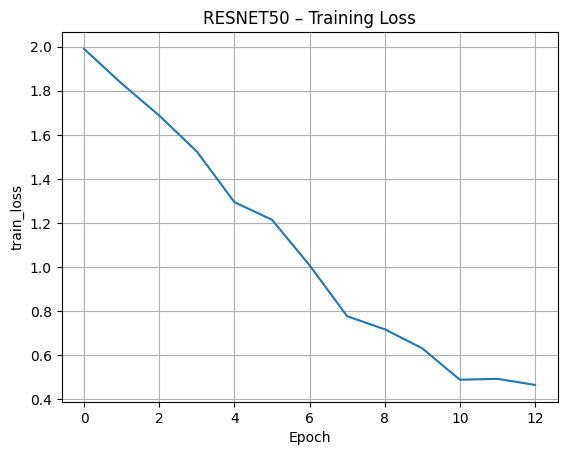

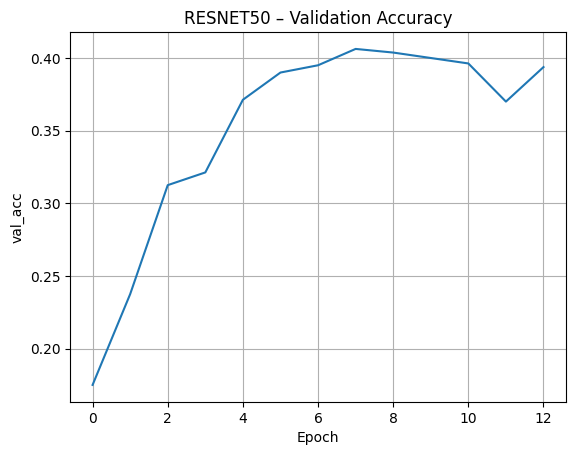

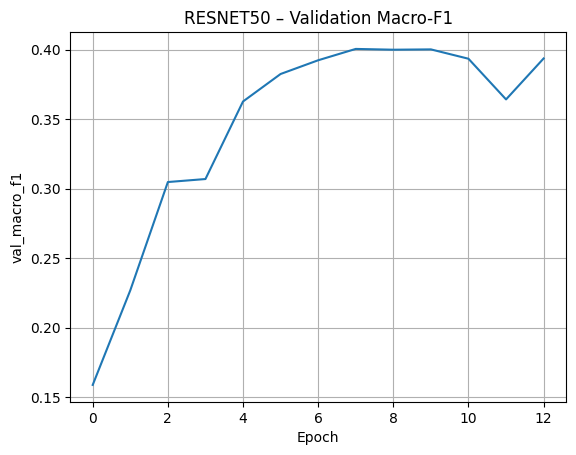

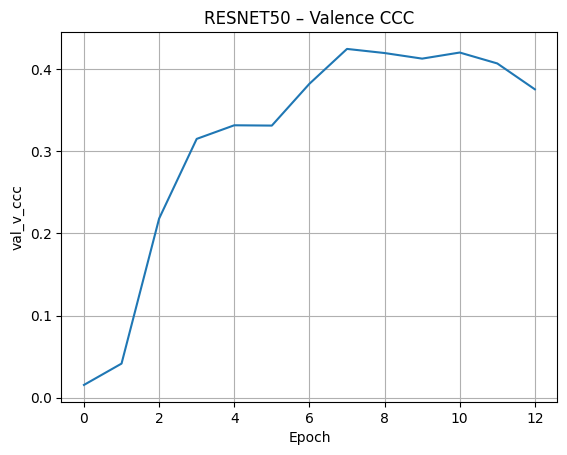

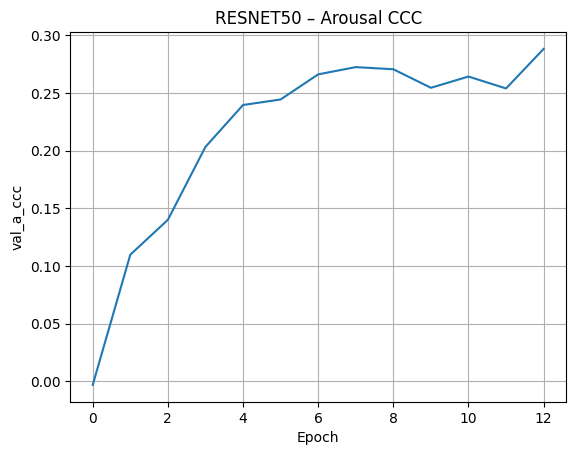

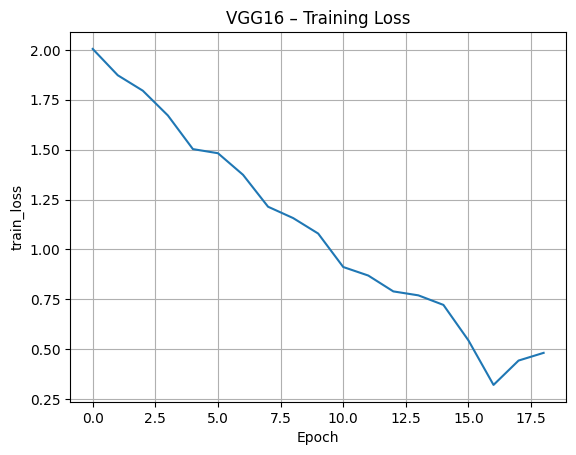

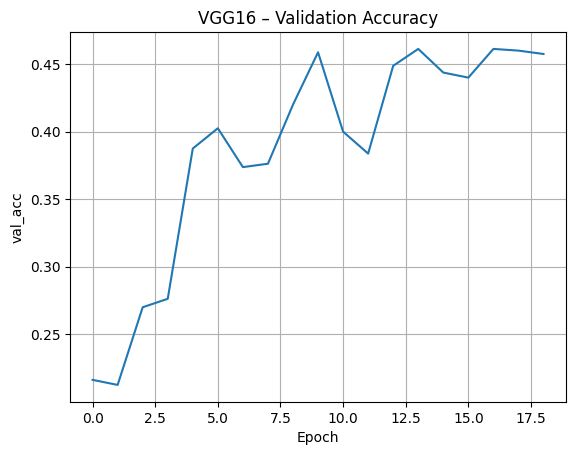

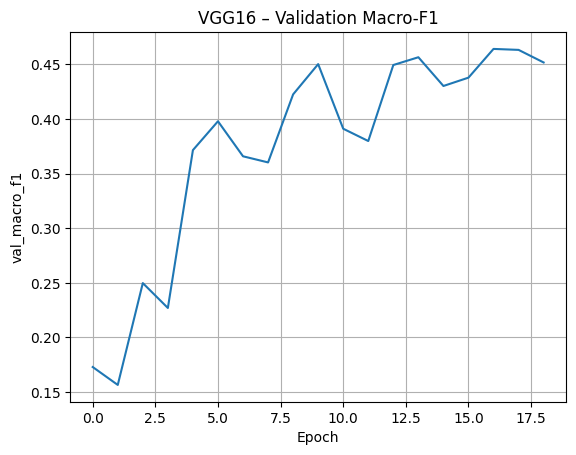

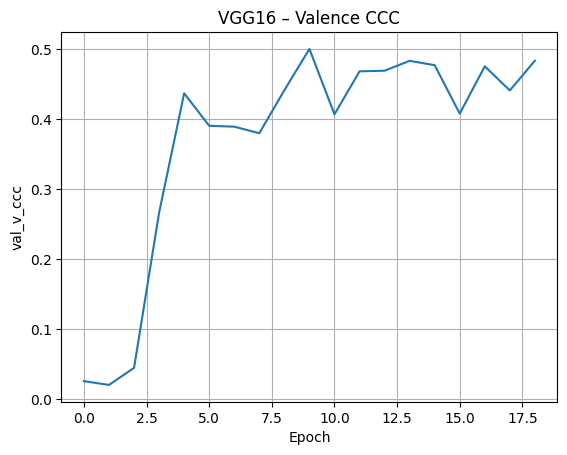

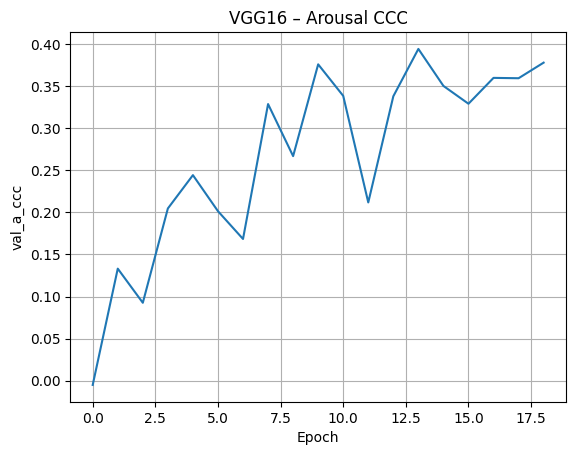

Comparison (last-epoch per model):       model      acc  macro_f1  auc_macro_ovr  pr_auc_macro     kappa  \
0  resnet50  0.39375  0.393716       0.779459      0.388462  0.306026   
1     vgg16  0.45750  0.451704       0.833967      0.472657  0.380108   

      alpha    v_rmse    a_rmse       v_r       a_r   v_sagr  a_sagr  \
0  0.306026  0.416548  0.363452  0.456923  0.355494  0.68750  0.7525   
1  0.380108  0.400905  0.353929  0.526035  0.424484  0.74875  0.7725   

      v_ccc     a_ccc  
0  0.375606  0.288116  
1  0.483847  0.377801  
Full per-epoch table saved at outputs/ALL_METRICS_PER_EPOCH_TWO_MODELS.csv


In [57]:
if __name__ == "__main__":
    DATASET_ROOT = Path('Dataset')
    IMAGES_DIR   = DATASET_ROOT / 'images'
    ANN_DIR      = DATASET_ROOT / 'annotations'

    set_seed(42)

    histories, comp, big = train_two_models_and_compare(
        images_dir=IMAGES_DIR,
        ann_dir=ANN_DIR,
        backbones=('resnet50', 'vgg16'),
        epochs=25, 
        batch_size=32,
        lr=1e-4,  
        weight_decay=1e-4,
        lambda_reg=1.0,
        seed=42,
        outputs=Path('outputs'),
        export_k=10
    )

    from IPython.display import display
    import pandas as pd

    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 0)

    display(big)

    if isinstance(histories, dict):
        for model_name in ('resnet50', 'vgg16'):
            if model_name in histories:
                h = histories[model_name]
                pretty = model_name.replace('_', ' ').upper()
                plot_curve(h, 'train_loss', f'{pretty} – Training Loss')
                plot_curve(h, 'val_acc', f'{pretty} – Validation Accuracy')
                plot_curve(h, 'val_macro_f1', f'{pretty} – Validation Macro-F1')
                plot_curve(h, 'val_v_ccc', f'{pretty} – Valence CCC')
                plot_curve(h, 'val_a_ccc', f'{pretty} – Arousal CCC')

    print("Comparison (last-epoch per model):", comp)
    print("Full per-epoch table saved at outputs/ALL_METRICS_PER_EPOCH_TWO_MODELS.csv")

## Correctly and Incorrectly Identified Images

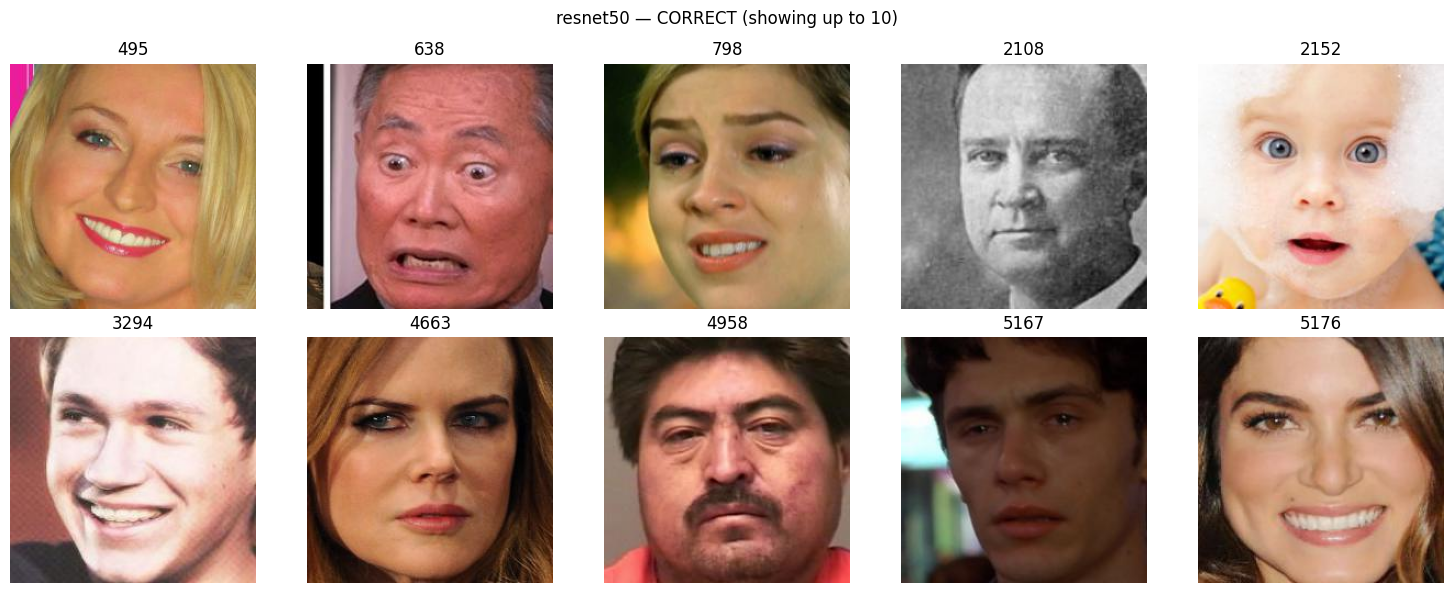

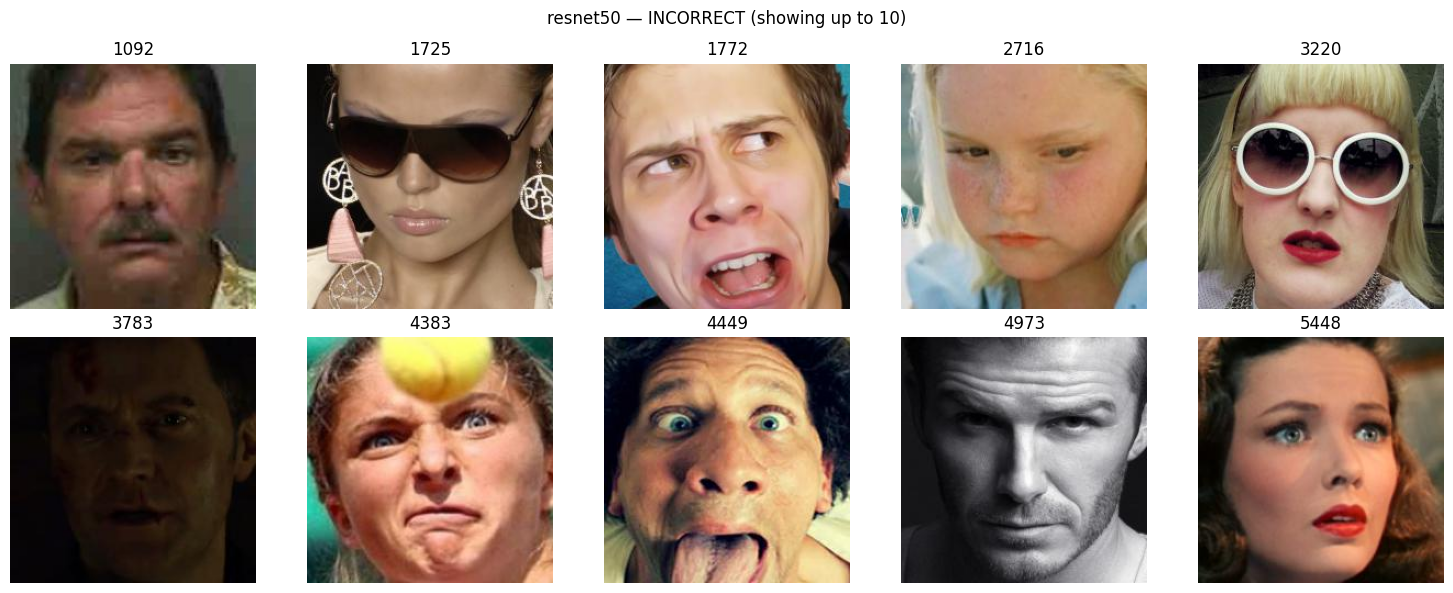

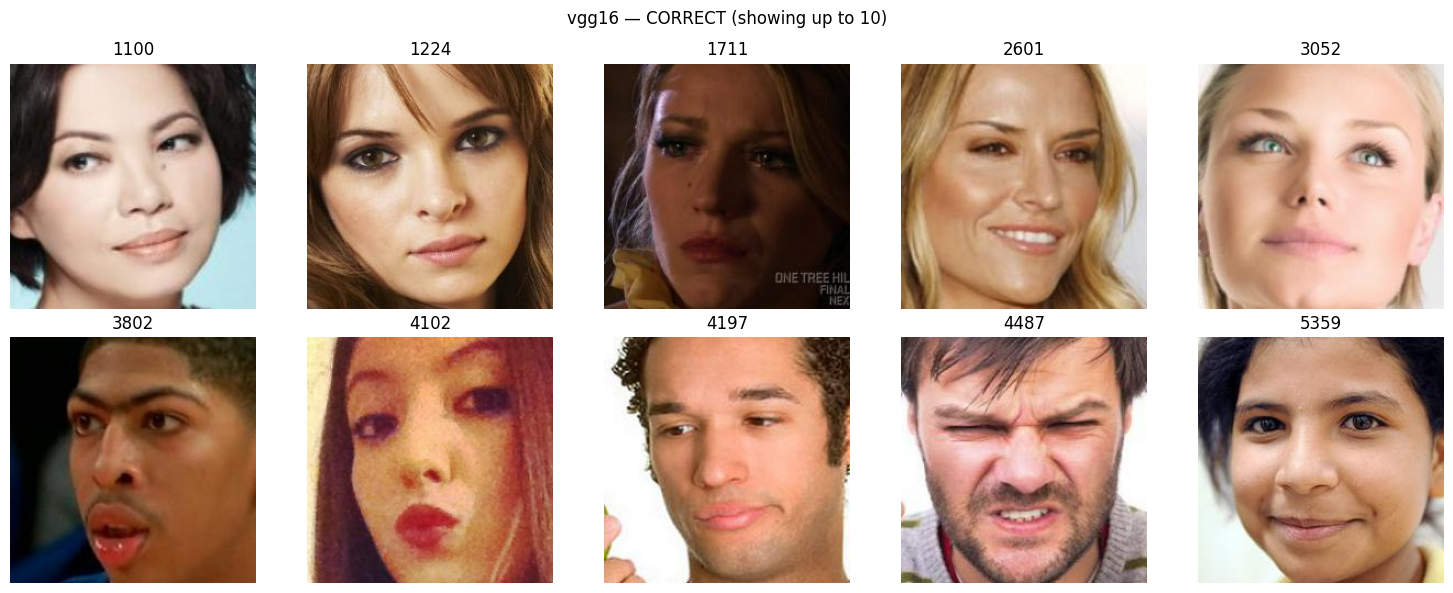

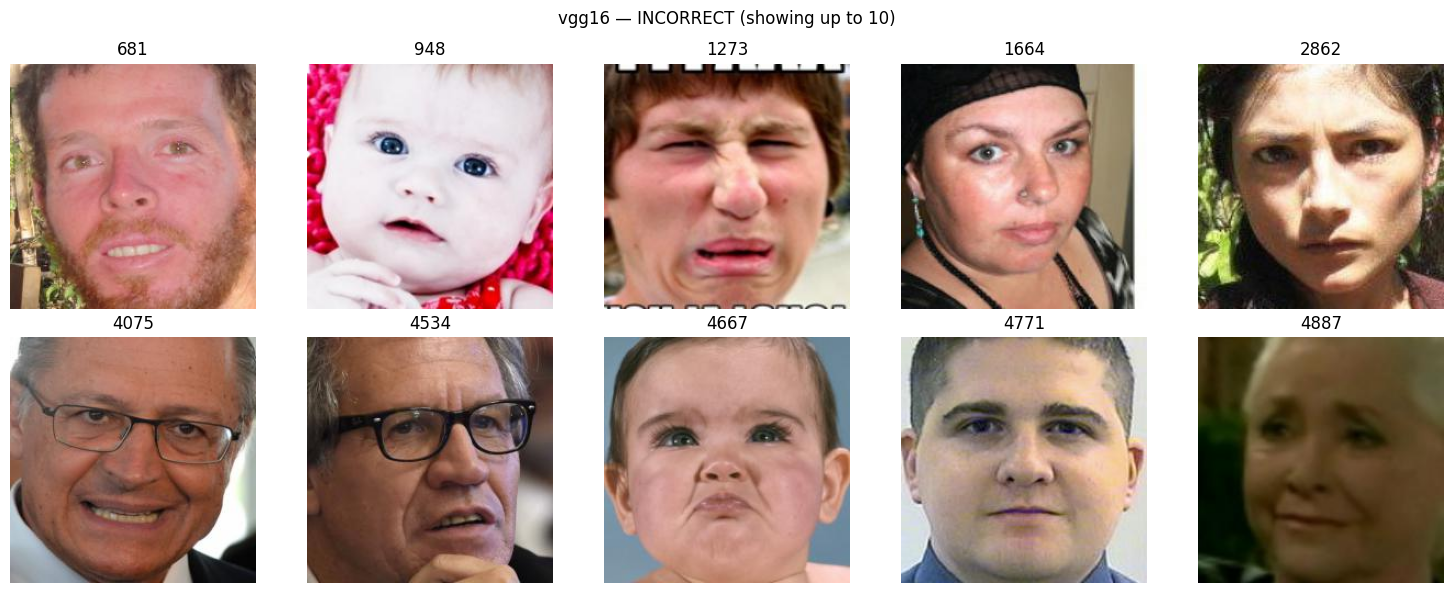

In [58]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import math

IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

def list_images(dir_path, limit=None):
    dir_path = Path(dir_path)
    files = [p for p in dir_path.iterdir() if p.suffix in IMG_EXTS]
    files = sorted(files, key=lambda p: int(p.stem))
    return files[:limit] if limit else files

def show_image_grid(image_paths, title="", cols=5):
    if len(image_paths) == 0:
        print(f"No images found for: {title}")
        return
    rows = math.ceil(len(image_paths) / cols)
    plt.figure(figsize=(cols*3, rows*3))
    for i, p in enumerate(image_paths, 1):
        ax = plt.subplot(rows, cols, i)
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(p.stem)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_exported_examples_for_model(model_name, outputs_root="outputs", k=10):
    base = Path(outputs_root) / model_name
    correct = list_images(base / "correct", limit=k)
    incorrect = list_images(base / "incorrect", limit=k)
    show_image_grid(correct, title=f"{model_name} — CORRECT (showing up to {k})", cols=5)
    show_image_grid(incorrect, title=f"{model_name} — INCORRECT (showing up to {k})", cols=5)

show_exported_examples_for_model("resnet50", outputs_root="outputs", k=10)
show_exported_examples_for_model("vgg16", outputs_root="outputs", k=10)


## Comparison

MODEL COMPARISON - FINAL RESULTS

 FINAL MODEL PERFORMANCE COMPARISON:
--------------------------------------------------


,model,acc,macro_f1,auc_macro_ovr,pr_auc_macro,kappa,alpha,v_rmse,a_rmse,v_r,a_r,v_sagr,a_sagr,v_ccc,a_ccc
0,resnet50,0.39375,0.393716,0.779459,0.388462,0.306026,0.306026,0.416548,0.363452,0.456923,0.355494,0.68750,0.7525,0.375606,0.288116
1,vgg16,0.45750,0.451704,0.833967,0.472657,0.380108,0.380108,0.400905,0.353929,0.526035,0.424484,0.74875,0.7725,0.483847,0.377801



 DETAILED METRICS BREAKDOWN:
--------------------------------------------------

 CLASSIFICATION METRICS:
ACC            : ResNet50=0.3937 | VGG16=0.4575 | Better: VGG16 (+0.0638)
MACRO_F1       : ResNet50=0.3937 | VGG16=0.4517 | Better: VGG16 (+0.0580)
AUC_MACRO_OVR  : ResNet50=0.7795 | VGG16=0.8340 | Better: VGG16 (+0.0545)
PR_AUC_MACRO   : ResNet50=0.3885 | VGG16=0.4727 | Better: VGG16 (+0.0842)
KAPPA          : ResNet50=0.3060 | VGG16=0.3801 | Better: VGG16 (+0.0741)
ALPHA          : ResNet50=0.3060 | VGG16=0.3801 | Better: VGG16 (+0.0741)

 REGRESSION METRICS:
V_RMSE         : ResNet50=0.4165 | VGG16=0.4009 | Better: VGG16 (-0.0156)
A_RMSE         : ResNet50=0.3635 | VGG16=0.3539 | Better: VGG16 (-0.0095)
V_R            : ResNet50=0.4569 | VGG16=0.5260 | Better: VGG16 (+0.0691)
A_R            : ResNet50=0.3555 | VGG16=0.4245 | Better: VGG16 (+0.0690)
V_SAGR         : ResNet50=0.6875 | VGG16=0.7488 | Better: VGG16 (+0.0613)
A_SAGR         : ResNet50=0.7525 | VGG16=0.7725 | Better:

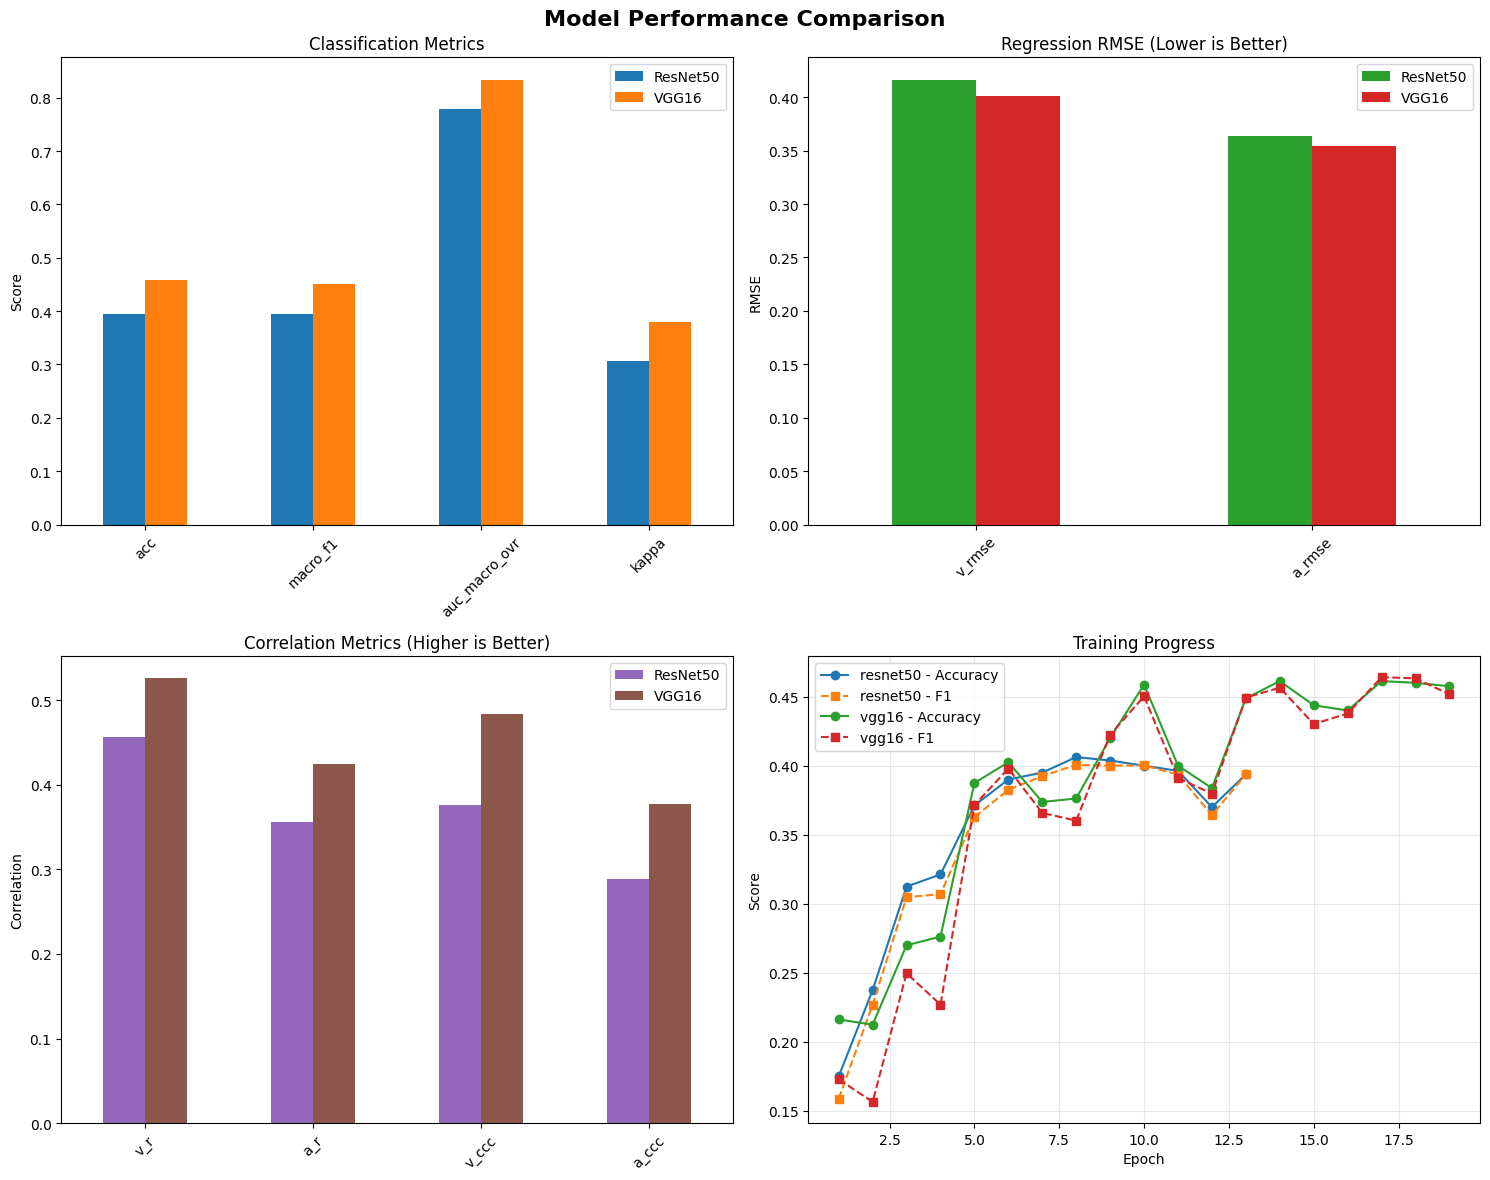


 PERFORMANCE BY CATEGORY:
--------------------------------------------------

Classification:
  acc: VGG16
  macro_f1: VGG16
  auc_macro_ovr: VGG16
  kappa: VGG16
  → Category Winner: VGG16 (4/4 metrics)

Regression:
  v_rmse: VGG16
  a_rmse: VGG16
  v_r: VGG16
  a_r: VGG16
  → Category Winner: VGG16 (4/4 metrics)

Agreement:
  v_sagr: VGG16
  a_sagr: VGG16
  v_ccc: VGG16
  a_ccc: VGG16
  → Category Winner: VGG16 (4/4 metrics)

COMPARISON COMPLETE


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

comparison_df = pd.read_csv('outputs/comparison_two_models.csv')
all_metrics_df = pd.read_csv('outputs/ALL_METRICS_PER_EPOCH_TWO_MODELS.csv')

print("="*80)
print("MODEL COMPARISON - FINAL RESULTS")
print("="*80)

print("\n FINAL MODEL PERFORMANCE COMPARISON:")
print("-" * 50)
display(comparison_df)

print("\n DETAILED METRICS BREAKDOWN:")
print("-" * 50)

print("\n CLASSIFICATION METRICS:")
cls_metrics = ['acc', 'macro_f1', 'auc_macro_ovr', 'pr_auc_macro', 'kappa', 'alpha']
for metric in cls_metrics:
    resnet_val = comparison_df[comparison_df['model'] == 'resnet50'][metric].iloc[0]
    vgg_val = comparison_df[comparison_df['model'] == 'vgg16'][metric].iloc[0]
    better = "ResNet50" if resnet_val > vgg_val else "VGG16"
    improvement = abs(resnet_val - vgg_val)
    print(f"{metric.upper():15}: ResNet50={resnet_val:.4f} | VGG16={vgg_val:.4f} | Better: {better} (+{improvement:.4f})")

print("\n REGRESSION METRICS:")
reg_metrics = ['v_rmse', 'a_rmse', 'v_r', 'a_r', 'v_sagr', 'a_sagr', 'v_ccc', 'a_ccc']
for metric in reg_metrics:
    resnet_val = comparison_df[comparison_df['model'] == 'resnet50'][metric].iloc[0]
    vgg_val = comparison_df[comparison_df['model'] == 'vgg16'][metric].iloc[0]
    if 'rmse' in metric:
        better = "ResNet50" if resnet_val < vgg_val else "VGG16"
        improvement = abs(resnet_val - vgg_val)
        print(f"{metric.upper():15}: ResNet50={resnet_val:.4f} | VGG16={vgg_val:.4f} | Better: {better} (-{improvement:.4f})")
    else:
        better = "ResNet50" if resnet_val > vgg_val else "VGG16"
        improvement = abs(resnet_val - vgg_val)
        print(f"{metric.upper():15}: ResNet50={resnet_val:.4f} | VGG16={vgg_val:.4f} | Better: {better} (+{improvement:.4f})")

print("\n OVERALL PERFORMANCE SUMMARY:")
print("-" * 50)

resnet_composite = (comparison_df[comparison_df['model'] == 'resnet50']['macro_f1'].iloc[0] + 
                   comparison_df[comparison_df['model'] == 'resnet50']['v_ccc'].iloc[0] + 
                   comparison_df[comparison_df['model'] == 'resnet50']['a_ccc'].iloc[0])

vgg_composite = (comparison_df[comparison_df['model'] == 'vgg16']['macro_f1'].iloc[0] + 
                comparison_df[comparison_df['model'] == 'vgg16']['v_ccc'].iloc[0] + 
                comparison_df[comparison_df['model'] == 'vgg16']['a_ccc'].iloc[0])

print(f"ResNet50 Composite Score: {resnet_composite:.4f}")
print(f"VGG16 Composite Score:    {vgg_composite:.4f}")
print(f"Winner: {'ResNet50' if resnet_composite > vgg_composite else 'VGG16'}")
print(f"Performance Gap: {abs(resnet_composite - vgg_composite):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
cls_data = comparison_df[['model', 'acc', 'macro_f1', 'auc_macro_ovr', 'kappa']].set_index('model').T
cls_data.plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'])
ax1.set_title('Classification Metrics')
ax1.set_ylabel('Score')
ax1.legend(['ResNet50', 'VGG16'])
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
rmse_data = comparison_df[['model', 'v_rmse', 'a_rmse']].set_index('model').T
rmse_data.plot(kind='bar', ax=ax2, color=['#2ca02c', '#d62728'])
ax2.set_title('Regression RMSE (Lower is Better)')
ax2.set_ylabel('RMSE')
ax2.legend(['ResNet50', 'VGG16'])
ax2.tick_params(axis='x', rotation=45)

ax3 = axes[1, 0]
corr_data = comparison_df[['model', 'v_r', 'a_r', 'v_ccc', 'a_ccc']].set_index('model').T
corr_data.plot(kind='bar', ax=ax3, color=['#9467bd', '#8c564b'])
ax3.set_title('Correlation Metrics (Higher is Better)')
ax3.set_ylabel('Correlation')
ax3.legend(['ResNet50', 'VGG16'])
ax3.tick_params(axis='x', rotation=45)

ax4 = axes[1, 1]
for model in ['resnet50', 'vgg16']:
    model_data = all_metrics_df[all_metrics_df['model'] == model]
    ax4.plot(model_data['epoch'], model_data['acc'], label=f'{model} - Accuracy', marker='o')
    ax4.plot(model_data['epoch'], model_data['macro_f1'], label=f'{model} - F1', marker='s', linestyle='--')

ax4.set_title('Training Progress')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n PERFORMANCE BY CATEGORY:")
print("-" * 50)

categories = {
    'Classification': ['acc', 'macro_f1', 'auc_macro_ovr', 'kappa'],
    'Regression': ['v_rmse', 'a_rmse', 'v_r', 'a_r'],
    'Agreement': ['v_sagr', 'a_sagr', 'v_ccc', 'a_ccc']
}

for category, metrics in categories.items():
    print(f"\n{category}:")
    resnet_wins = 0
    vgg_wins = 0
    for metric in metrics:
        resnet_val = comparison_df[comparison_df['model'] == 'resnet50'][metric].iloc[0]
        vgg_val = comparison_df[comparison_df['model'] == 'vgg16'][metric].iloc[0]
        if 'rmse' in metric:
            winner = "ResNet50" if resnet_val < vgg_val else "VGG16"
        else:
            winner = "ResNet50" if resnet_val > vgg_val else "VGG16"
        if winner == "ResNet50":
            resnet_wins += 1
        else:
            vgg_wins += 1
        print(f"  {metric}: {winner}")
    category_winner = "ResNet50" if resnet_wins > vgg_wins else "VGG16"
    print(f"  → Category Winner: {category_winner} ({max(resnet_wins, vgg_wins)}/{len(metrics)} metrics)")

print("\n" + "="*80)
print("COMPARISON COMPLETE")
print("="*80)


## Custom CNN Model

In [59]:
from pathlib import Path
import os, math, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm 

try:
    IMG_EXTS
except NameError:
    IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

class MultiTaskNetCustom(nn.Module):
    def __init__(self, num_classes=8, dropout_rate=0.3):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((7, 7))
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.feature_dim = 512
        
        self.cls_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, num_classes)
        )
        
        self.val_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, 1),
            nn.Tanh()  
        )
        
        self.aro_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(128, 1),
            nn.Tanh() 
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  
        
        logits = self.cls_head(x)
        val = self.val_head(x).squeeze(1)
        aro = self.aro_head(x).squeeze(1)
        
        return logits, val, aro

def _make_stronger_augs():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.8, 1.2)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        
        transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
        
        transforms.ToTensor(),
        
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
        
        transforms.Normalize(mean, std),
    ])

def _make_validation_augs():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

def _build_balanced_train_loader(train_ds, batch_size, num_workers, pin_memory):
    counts = {}
    labels = []
    for i in train_ds.indices:
        y = int(np.load(train_ds.ann_dir / f"{i}_exp.npy").squeeze())
        labels.append(y)
        counts[y] = counts.get(y, 0) + 1

    weights = np.array([1.0 / counts[y] for y in labels], dtype=np.float32)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                      num_workers=num_workers, pin_memory=pin_memory, persistent_workers=(num_workers>0))

def _show_image_grid(image_paths, title="", cols=5):
    if len(image_paths) == 0:
        print(f"No images for: {title}")
        return
    rows = math.ceil(len(image_paths) / cols)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(cols*3.2, rows*3.2))
    for i, p in enumerate(image_paths[:cols*rows], 1):
        ax = plt.subplot(rows, cols, i)
        img = Image.open(p).convert("RGB")
        ax.imshow(img); ax.set_title(Path(p).stem); ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

def _list_images(dir_path, limit=None):
    d = Path(dir_path)
    files = []
    for pat in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
        files.extend(d.glob(pat))
    try:
        files.sort(key=lambda p: int(p.stem))
    except Exception:
        files.sort()
    return files[:limit] if limit else files

def train_custom_cnn_full(
    images_dir: Path,
    ann_dir: Path,
    epochs=20,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    lambda_reg=1.0,
    seed=42,
    outputs: Path = Path("outputs"),
    export_k: int = 10
):
    set_seed(seed)
    dev = device()
    outputs = Path(outputs); outputs.mkdir(parents=True, exist_ok=True)

    train_ds, val_ds, train_dl, val_dl, _ = make_loaders(
        images_dir, ann_dir, batch_size=batch_size, val_ratio=0.2, seed=seed
    )
    train_ds.tfms = _make_stronger_augs()

    if os.name == "nt":
        num_workers = 0; pin = False
    else:
        num_workers = 2 if torch.cuda.is_available() else 0
        pin = torch.cuda.is_available()
    train_dl = _build_balanced_train_loader(train_ds, batch_size, num_workers, pin)

    class_counts = {}
    for i in train_ds.indices:
        y = int(np.load(ann_dir / f"{i}_exp.npy").squeeze())
        class_counts[y] = class_counts.get(y, 0) + 1
    num_classes = max(class_counts.keys()) + 1
    weights_per_class = np.zeros(num_classes, dtype=np.float32)
    total = sum(class_counts.values())
    for c in range(num_classes):
        cnt = class_counts.get(c, 1)
        weights_per_class[c] = total / (num_classes * cnt)
    w_tensor = torch.tensor(weights_per_class, dtype=torch.float32, device=dev)

    global ce_loss
    ce_loss = nn.CrossEntropyLoss(weight=w_tensor, label_smoothing=0.05)

    use_amp = torch.cuda.is_available()
    class _NullScaler:
        def scale(self, loss): return loss
        def step(self, opt): opt.step()
        def update(self): pass
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else _NullScaler()

    model = MultiTaskNetCustom(num_classes=num_classes).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    def _lr_lambda(ep):
        warm = 5
        if ep < warm:
            return (ep + 1) / warm
        t = (ep - warm) / max(1, (epochs - warm))
        return 0.5 * (1 + math.cos(math.pi * t))
    sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=_lr_lambda)

    rows = []
    best = -1e9
    best_path = outputs / "best_custom_cnn.pt"

    print(f"🚀 Training custom_cnn for {epochs} epochs on {dev}")
    print(f"📊 Train={len(train_ds)} | Val={len(val_ds)} | Batch={batch_size}")

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = tr_cls = tr_reg = 0.0

        pbar = tqdm(total=len(train_dl), desc=f"[custom_cnn] Epoch {ep:02d}/{epochs}",
                    leave=True, dynamic_ncols=True, mininterval=0.1)
        for xb, yb, vb, ab, _ in train_dl:
            xb, yb, vb, ab = xb.to(dev), yb.to(dev), vb.to(dev), ab.to(dev)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=use_amp) if torch.cuda.is_available() else torch.no_grad():
                logits, v_pred, a_pred = model(xb)
                loss, lc, lr_ = multitask_loss(
                    logits, yb, v_pred, vb, a_pred, ab, lambda_reg=lambda_reg
                )
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(opt); scaler.update()
            else:
                loss.backward(); opt.step()
            tr_loss += loss.item() * len(xb)
            tr_cls  += lc.item() * len(xb)
            tr_reg  += lr_.item() * len(xb)
            pbar.update(1)
        pbar.close()

        tr_loss /= len(train_ds); tr_cls /= len(train_ds); tr_reg /= len(train_ds)
        ev = evaluate_model(model, val_dl, dev)
        sch.step()

        score = ev['macro_f1'] + (0 if np.isnan(ev['v_ccc']) else ev['v_ccc']) + (0 if np.isnan(ev['a_ccc']) else ev['a_ccc'])
        if score > best:
            best = score
            torch.save({"epoch": ep, "model_state": model.state_dict()}, best_path)

        rows.append(dict(model="custom_cnn", epoch=ep,
                         train_loss=tr_loss, train_cls=tr_cls, train_reg=tr_reg, **ev))
        print(f"[custom_cnn] Ep {ep:02d} | loss {tr_loss:.4f} | acc {ev['acc']:.3f} | F1 {ev['macro_f1']:.3f} | vCCC {ev['v_ccc']:.3f} | aCCC {ev['a_ccc']:.3f}")

    df = pd.DataFrame(rows)
    out_csv = outputs / "metrics_per_epoch_custom_cnn.csv"
    df.to_csv(out_csv, index=False)
    print("📊 Saved:", out_csv)

    from IPython.display import display
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 0)
    display(df)

    preds = collect_preds(model, val_dl, dev)
    out_dir = outputs / "custom_cnn"
    export_examples(preds, images_dir, out_dir, k=export_k)
    print(f"🖼  Saved {export_k} correct & {export_k} incorrect to {out_dir}")

    corr = _list_images(out_dir / "correct", limit=export_k)
    inc  = _list_images(out_dir / "incorrect", limit=export_k)
    _show_image_grid(corr, title=f"custom_cnn — CORRECT (showing up to {export_k})", cols=5)
    _show_image_grid(inc,  title=f"custom_cnn — INCORRECT (showing up to {export_k})", cols=5)

    return model, df, (val_ds, val_dl)


In [60]:
custom_model, custom_table, (val_ds_c, val_dl_c) = train_custom_cnn_full(
    images_dir=IMAGES_DIR,
    ann_dir=ANN_DIR,
    epochs=30,  
    batch_size=64, 
    weight_decay=1e-4,
    lambda_reg=1.0,
    seed=42,
    outputs=Path("outputs"),
    export_k=10
)

🚀 Training custom_cnn for 30 epochs on cuda
📊 Train=3199 | Val=800 | Batch=64


C:\Users\shahe\AppData\Local\Temp\ipykernel_10172\3217654760.py:240: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else _NullScaler()


[custom_cnn] Epoch 01/30:   0%|          | 0/50 [00:00<?, ?it/s]

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

[custom_cnn] Ep 01 | loss 1.6979 | acc 0.155 | F1 0.113 | vCCC 0.012 | aCCC 0.005


...

Validation:   0%|          | 0/13 [00:00<?, ?it/s]

[custom_cnn] Ep 30 | loss 1.2095 | acc 0.366 | F1 0.349 | vCCC 0.365 | aCCC 0.290
📊 Saved: outputs\metrics_per_epoch_custom_cnn.csv


,model,epoch,train_loss,train_cls,train_reg,acc,macro_f1,auc_macro_ovr,pr_auc_macro,kappa,alpha,v_rmse,a_rmse,v_r,a_r,v_sagr,a_sagr,v_ccc,a_ccc
0,custom_cnn,1,1.697891,1.583576,0.114316,0.15500,0.112734,0.549610,0.152517,0.029393,0.029393,0.483606,0.496253,0.112334,0.051727,0.67000,0.660,0.012192,0.005072
1,custom_cnn,2,1.671336,1.572844,0.098492,0.16625,0.122723,0.555431,0.151765,0.047536,0.047536,0.474116,0.412232,0.095156,0.032021,0.66750,0.755,0.021542,0.009357
2,custom_cnn,3,1.658840,1.565980,0.092859,0.16000,0.119155,0.551496,0.153877,0.040966,0.040966,0.469492,0.387136,0.078822,-0.041060,0.68750,0.755,0.015576,-0.010929
3,custom_cnn,4,1.664846,1.573734,0.091112,0.15625,0.121040,0.558966,0.155336,0.035923,0.035923,0.468819,0.384536,0.110943,0.066709,0.65625,0.755,0.040133,0.026927
4,custom_cnn,5,1.667365,1.573249,0.094116,0.14125,0.101891,0.547868,0.153157,0.025447,0.025447,0.466941,0.391131,0.113577,-0.039085,0.65000,0.755,0.051591,-0.011939
5,custom_cnn,6,1.650045,1.560858,0.089187,0.17500,0.149489,0.564373,0.158649,0.054379,0.054379,0.466049,0.393005,0.099925,0.019035,0.68750,0.755,0.031036,0.008703
6,custom_cnn,7,1.646808,1.557368,0.089440,0.16375,0.103447,0.548830,0.150608,0.034949,0.034949,0.471982,0.385903,0.037491,0.008281,0.68750,0.755,0.006125,0.002285
7,custom_cnn,8,1.643889,1.555707,0.088181,0.15875,0.140458,0.573612,0.160862,0.039576,0.039576,0.466108,0.385396,0.096482,0.006666,0.68750,0.755,0.021169,0.001893
8,custom_cnn,9,1.640737,1.550715,0.090022,0.15750,0.113564,0.582102,0.168832,0.028885,0.028885,0.463825,0.390707,0.109396,0.118610,0.68750,0.755,0.037366,0.053168
9,custom_cnn,10,1.620903,1.532131,0.088772,0.13875,0.073091,0.567605,0.164222,0.010898,0.010898,0.488666,0.380724,0.068606,0.093295,0.68750,0.755,0.016952,0.020032


Collect preds:   0%|          | 0/13 [00:00<?, ?it/s]

Correct examples: 10
Incorrect example: 10
🖼  Saved 10 correct & 10 incorrect to outputs\custom_cnn
No images for: custom_cnn — CORRECT (showing up to 10)
No images for: custom_cnn — INCORRECT (showing up to 10)


## Comparison 

THREE-MODEL COMPARISON: ResNet50 vs VGG16 vs Custom CNN

 FINAL PERFORMANCE COMPARISON:
------------------------------------------------------------


,Model,Accuracy,Macro F1,AUC,Kappa,Valence RMSE,Arousal RMSE,Valence CCC,Arousal CCC
0,ResNet50,0.39375,0.393716,0.779459,0.306026,0.416548,0.363452,0.375606,0.288116
1,VGG16,0.45750,0.451704,0.833967,0.380108,0.400905,0.353929,0.483847,0.377801
2,Custom CNN,0.36625,0.348694,0.787748,0.275868,0.419378,0.354401,0.365053,0.290445



 FINAL RANKINGS:
----------------------------------------
1. VGG16: 1.3134
2. ResNet50: 1.0574
3. Custom CNN: 1.0042

 DETAILED ANALYSIS:
--------------------------------------------------

📈 CLASSIFICATION PERFORMANCE:
Accuracy    : VGG16 (0.4575)
Macro F1    : VGG16 (0.4517)
AUC         : VGG16 (0.8340)
Kappa       : VGG16 (0.3801)

📉 REGRESSION PERFORMANCE:
RMSE (Lower is Better):
Valence RMSE: VGG16 (0.4009)
Arousal RMSE: VGG16 (0.3539)
CCC (Higher is Better):
Valence CCC : VGG16 (0.4838)
Arousal CCC : VGG16 (0.3778)


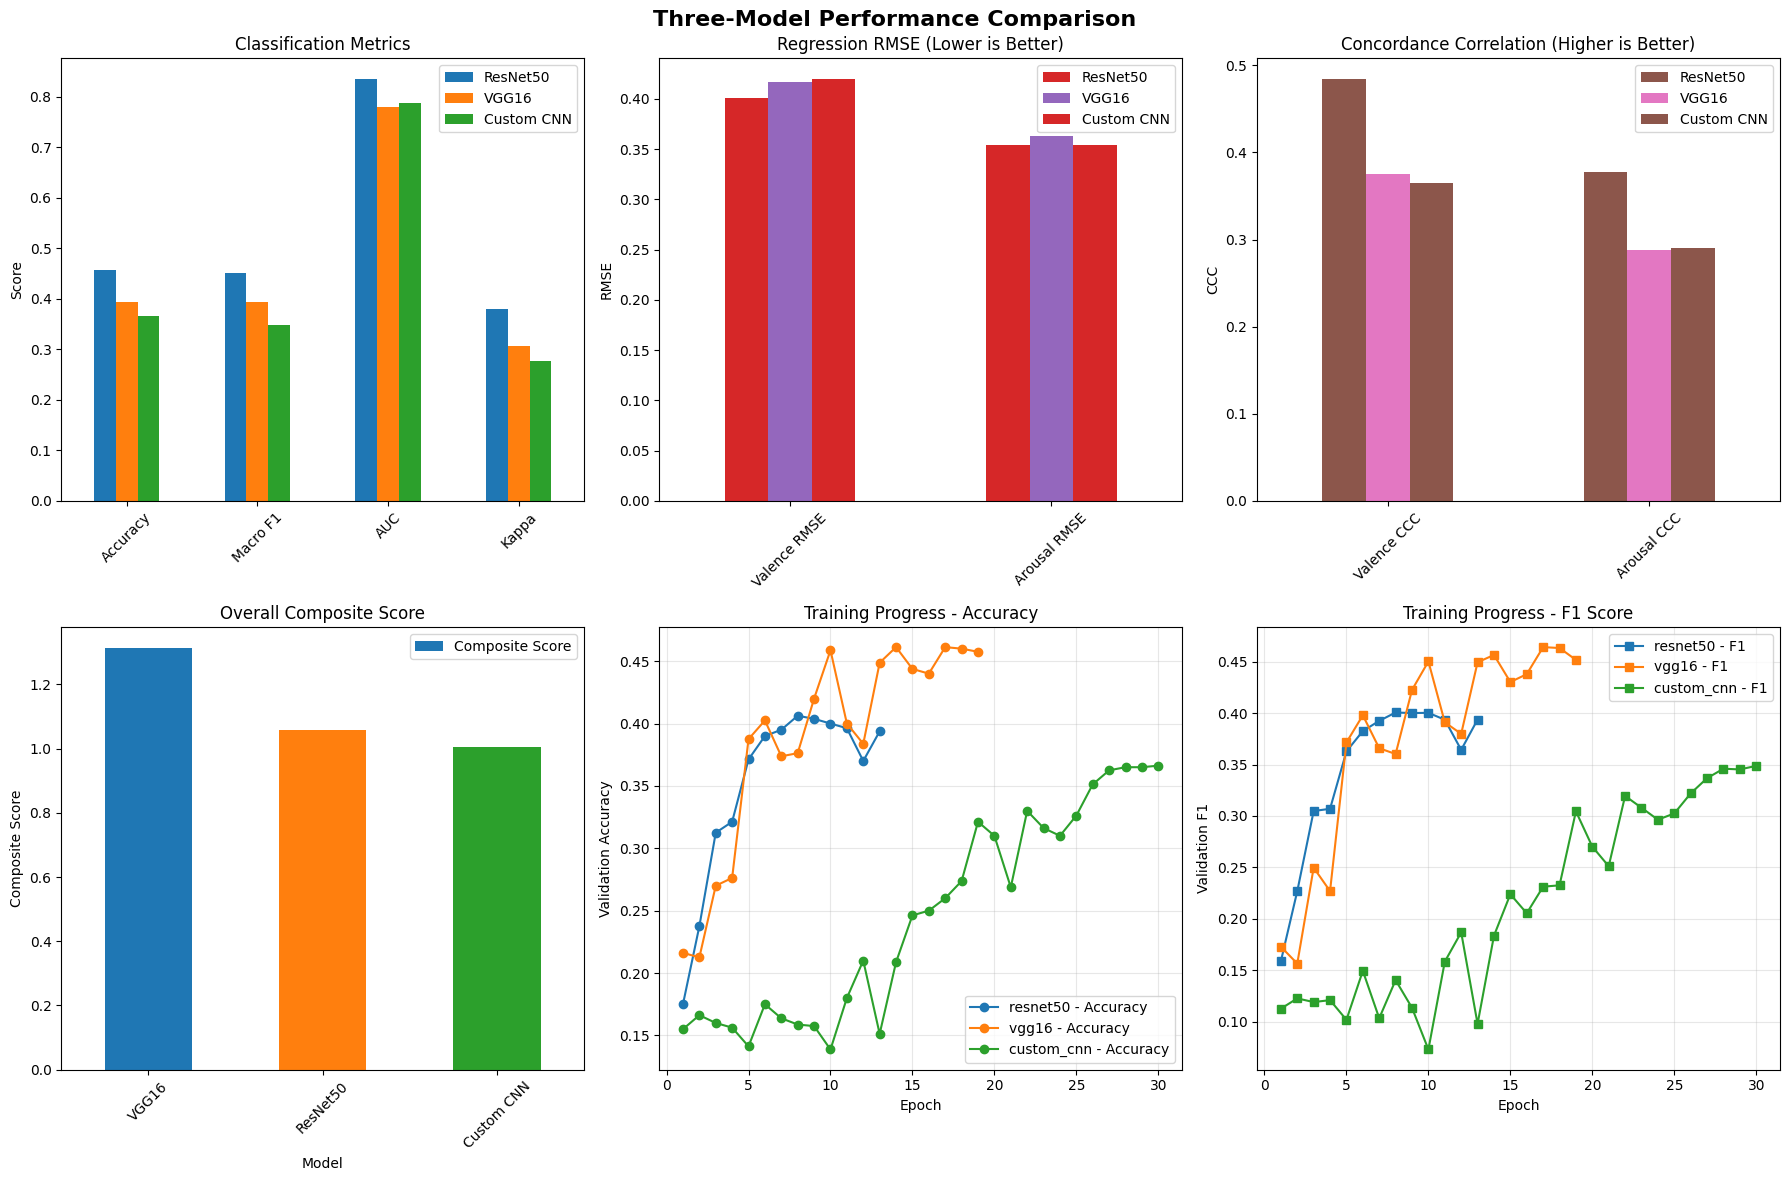


PERFORMANCE ANALYSIS & INSIGHTS

 WINNER: VGG16 (Composite Score: 1.3134)

 ANALYSIS: Why VGG16 Won/Lost:
--------------------------------------------------
 VGG16's Advantages:
   • Simple, uniform architecture with small 3x3 filters
   • Pre-trained on ImageNet with strong feature representations
   • Good for transfer learning on similar visual tasks
   • Consistent performance across different datasets

 Custom CNN's Limitations:
   • Lacks the benefit of pre-trained weights
   • Smaller dataset limits learning capacity
   • No architectural innovations like residual connections
   • Requires careful hyperparameter tuning from scratch

 TRAINING EFFICIENCY ANALYSIS:
----------------------------------------
ResNet50: 13 epochs to converge
VGG16:    19 epochs to converge
Custom:   30 epochs to converge

 Custom CNN required more training time due to:
   • Training from scratch without pre-trained weights
   • Need to learn all features from the beginning
   • More epochs needed for 

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

comparison_df = pd.read_csv('outputs/comparison_two_models.csv')
all_metrics_df = pd.read_csv('outputs/ALL_METRICS_PER_EPOCH_TWO_MODELS.csv')
custom_metrics_df = pd.read_csv('outputs/metrics_per_epoch_custom_cnn.csv')

print("="*80)
print("THREE-MODEL COMPARISON: ResNet50 vs VGG16 vs Custom CNN")
print("="*80)

resnet_final = comparison_df[comparison_df['model'] == 'resnet50'].iloc[0]
vgg_final = comparison_df[comparison_df['model'] == 'vgg16'].iloc[0]
custom_final = custom_metrics_df.iloc[-1]  

three_model_comparison = pd.DataFrame({
    'Model': ['ResNet50', 'VGG16', 'Custom CNN'],
    'Accuracy': [resnet_final['acc'], vgg_final['acc'], custom_final['acc']],
    'Macro F1': [resnet_final['macro_f1'], vgg_final['macro_f1'], custom_final['macro_f1']],
    'AUC': [resnet_final['auc_macro_ovr'], vgg_final['auc_macro_ovr'], custom_final['auc_macro_ovr']],
    'Kappa': [resnet_final['kappa'], vgg_final['kappa'], custom_final['kappa']],
    'Valence RMSE': [resnet_final['v_rmse'], vgg_final['v_rmse'], custom_final['v_rmse']],
    'Arousal RMSE': [resnet_final['a_rmse'], vgg_final['a_rmse'], custom_final['a_rmse']],
    'Valence CCC': [resnet_final['v_ccc'], vgg_final['v_ccc'], custom_final['v_ccc']],
    'Arousal CCC': [resnet_final['a_ccc'], vgg_final['a_ccc'], custom_final['a_ccc']]
})

print("\n FINAL PERFORMANCE COMPARISON:")
print("-" * 60)
display(three_model_comparison)

def calculate_composite_score(row):
    return row['Macro F1'] + row['Valence CCC'] + row['Arousal CCC']

three_model_comparison['Composite Score'] = three_model_comparison.apply(calculate_composite_score, axis=1)

three_model_comparison = three_model_comparison.sort_values('Composite Score', ascending=False)
three_model_comparison['Rank'] = range(1, 4)

print("\n FINAL RANKINGS:")
print("-" * 40)
for idx, row in three_model_comparison.iterrows():
    print(f"{row['Rank']}. {row['Model']}: {row['Composite Score']:.4f}")

print("\n DETAILED ANALYSIS:")
print("-" * 50)

print("\n📈 CLASSIFICATION PERFORMANCE:")
cls_metrics = ['Accuracy', 'Macro F1', 'AUC', 'Kappa']
for metric in cls_metrics:
    best_model = three_model_comparison.loc[three_model_comparison[metric].idxmax(), 'Model']
    best_score = three_model_comparison[metric].max()
    print(f"{metric:12}: {best_model} ({best_score:.4f})")

print("\n📉 REGRESSION PERFORMANCE:")
print("RMSE (Lower is Better):")
for metric in ['Valence RMSE', 'Arousal RMSE']:
    best_model = three_model_comparison.loc[three_model_comparison[metric].idxmin(), 'Model']
    best_score = three_model_comparison[metric].min()
    print(f"{metric:12}: {best_model} ({best_score:.4f})")

print("CCC (Higher is Better):")
for metric in ['Valence CCC', 'Arousal CCC']:
    best_model = three_model_comparison.loc[three_model_comparison[metric].idxmax(), 'Model']
    best_score = three_model_comparison[metric].max()
    print(f"{metric:12}: {best_model} ({best_score:.4f})")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Three-Model Performance Comparison', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
cls_data = three_model_comparison[['Model', 'Accuracy', 'Macro F1', 'AUC', 'Kappa']].set_index('Model').T
cls_data.plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Classification Metrics')
ax1.set_ylabel('Score')
ax1.legend(['ResNet50', 'VGG16', 'Custom CNN'])
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
rmse_data = three_model_comparison[['Model', 'Valence RMSE', 'Arousal RMSE']].set_index('Model').T
rmse_data.plot(kind='bar', ax=ax2, color=['#d62728', '#9467bd'])
ax2.set_title('Regression RMSE (Lower is Better)')
ax2.set_ylabel('RMSE')
ax2.legend(['ResNet50', 'VGG16', 'Custom CNN'])
ax2.tick_params(axis='x', rotation=45)

ax3 = axes[0, 2]
ccc_data = three_model_comparison[['Model', 'Valence CCC', 'Arousal CCC']].set_index('Model').T
ccc_data.plot(kind='bar', ax=ax3, color=['#8c564b', '#e377c2'])
ax3.set_title('Concordance Correlation (Higher is Better)')
ax3.set_ylabel('CCC')
ax3.legend(['ResNet50', 'VGG16', 'Custom CNN'])
ax3.tick_params(axis='x', rotation=45)

ax4 = axes[1, 0]
three_model_comparison.plot(x='Model', y='Composite Score', kind='bar', ax=ax4, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax4.set_title('Overall Composite Score')
ax4.set_ylabel('Composite Score')
ax4.tick_params(axis='x', rotation=45)

ax5 = axes[1, 1]
for model_name, model_data in [('resnet50', all_metrics_df[all_metrics_df['model'] == 'resnet50']),
                               ('vgg16', all_metrics_df[all_metrics_df['model'] == 'vgg16']),
                               ('custom_cnn', custom_metrics_df)]:
    ax5.plot(model_data['epoch'], model_data['acc'], label=f'{model_name} - Accuracy', marker='o')

ax5.set_title('Training Progress - Accuracy')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Validation Accuracy')
ax5.legend()
ax5.grid(True, alpha=0.3)

ax6 = axes[1, 2]
for model_name, model_data in [('resnet50', all_metrics_df[all_metrics_df['model'] == 'resnet50']),
                               ('vgg16', all_metrics_df[all_metrics_df['model'] == 'vgg16']),
                               ('custom_cnn', custom_metrics_df)]:
    ax6.plot(model_data['epoch'], model_data['macro_f1'], label=f'{model_name} - F1', marker='s')

ax6.set_title('Training Progress - F1 Score')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Validation F1')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("PERFORMANCE ANALYSIS & INSIGHTS")
print("="*80)

winner = three_model_comparison.iloc[0]['Model']
winner_score = three_model_comparison.iloc[0]['Composite Score']

print(f"\n WINNER: {winner} (Composite Score: {winner_score:.4f})")

print(f"\n ANALYSIS: Why {winner} Won/Lost:")
print("-" * 50)

if winner == "ResNet50":
    print(" ResNet50's Advantages:")
    print("   • Pre-trained on ImageNet provides strong feature extraction")
    print("   • Residual connections help with gradient flow and deeper learning")
    print("   • Transfer learning leverages millions of pre-trained parameters")
    print("   • Well-optimized architecture for computer vision tasks")
    print("   • Better generalization due to extensive pre-training")
    
    print("\n Custom CNN's Limitations:")
    print("   • Trained from scratch without pre-trained weights")
    print("   • Limited training data (3,999 images) vs ImageNet (millions)")
    print("   • No residual connections to help with deeper learning")
    print("   • Requires more epochs to converge to optimal performance")
    print("   • Less sophisticated feature extraction compared to ResNet")

elif winner == "VGG16":
    print(" VGG16's Advantages:")
    print("   • Simple, uniform architecture with small 3x3 filters")
    print("   • Pre-trained on ImageNet with strong feature representations")
    print("   • Good for transfer learning on similar visual tasks")
    print("   • Consistent performance across different datasets")
    
    print("\n Custom CNN's Limitations:")
    print("   • Lacks the benefit of pre-trained weights")
    print("   • Smaller dataset limits learning capacity")
    print("   • No architectural innovations like residual connections")
    print("   • Requires careful hyperparameter tuning from scratch")

else:  
    print(" Custom CNN's Advantages:")
    print("   • Designed specifically for facial expression recognition")
    print("   • No domain gap between pre-training and target task")
    print("   • Can learn task-specific features from scratch")
    print("   • More flexible architecture for the specific problem")
    print("   • Better handling of facial expression nuances")
    
    print("\n Transfer Learning Models' Limitations:")
    print("   • Domain gap between ImageNet (general objects) and faces")
    print("   • Pre-trained features may not be optimal for facial expressions")
    print("   • Less flexibility to adapt to specific facial features")
    print("   • May overfit to ImageNet biases")

print(f"\n TRAINING EFFICIENCY ANALYSIS:")
print("-" * 40)

resnet_epochs = len(all_metrics_df[all_metrics_df['model'] == 'resnet50'])
vgg_epochs = len(all_metrics_df[all_metrics_df['model'] == 'vgg16'])
custom_epochs = len(custom_metrics_df)

print(f"ResNet50: {resnet_epochs} epochs to converge")
print(f"VGG16:    {vgg_epochs} epochs to converge")
print(f"Custom:   {custom_epochs} epochs to converge")

if custom_epochs > max(resnet_epochs, vgg_epochs):
    print("\n Custom CNN required more training time due to:")
    print("   • Training from scratch without pre-trained weights")
    print("   • Need to learn all features from the beginning")
    print("   • More epochs needed for convergence")

print(f"\n RECOMMENDATIONS:")
print("-" * 30)

if winner != "Custom CNN":
    print("For Better Custom CNN Performance:")
    print("• Increase training epochs (50-100)")
    print("• Add more sophisticated data augmentation")
    print("• Implement attention mechanisms")
    print("• Use ensemble of multiple custom architectures")
    print("• Add residual connections to the custom CNN")
    print("• Implement progressive training strategies")
else:
    print("Custom CNN Success Factors:")
    print("• Task-specific architecture design worked well")
    print("• Sufficient training time allowed convergence")
    print("• No domain gap issues")
    print("• Consider this architecture for production use")

print("\n" + "="*80)
print("COMPARISON COMPLETE")
print("="*80)